In [1]:
import numpy as np
from scipy.special import expit

kb = 8.617e-2  # meV/K
def free_energy(Dv, energies, T):
    """
    F(phi, T) = -kbT * sum_n ln(1 + exp(-e_n / kbT))
    Uses cosh identity for numerical stability.
    """
    kbT = kb * T
    F_list = []
    for ens in energies:
        ens_clean = ens[~np.isnan(ens)]
        # Sum over all states using cosh form
        #F_list.append(-kbT * np.sum(np.log(2 + 2*np.cosh(ens_clean / kbT))))
        F_list.append(-kbT * np.sum(np.log(1 + np.exp(-ens_clean / kbT))))
    return np.array(F_list)

def entropy(Dv, energies, T, dT=1e-6):
    """
    S = -dF/dT
    Calculate entropy from free energy using central finite difference
    """
    F_plus = free_energy(Dv, energies, T + dT)
    F_minus = free_energy(Dv, energies, T - dT)
    return -(F_plus - F_minus) / (2 * dT)

def internal_energy(Dv, energies, T):
    """
    U = F + TS
    Calculate internal energy from free energy and entropy
    """
    F = free_energy(Dv, energies, T)
    S = entropy(Dv, energies, T)
    return F + T * S

# Optional: Specific heat if needed
def specific_heat(Dv, energies, T, dT=1e-6):
    """
    C = dU/dT = T * dS/dT
    Calculate specific heat from internal energy
    """
    U_plus = internal_energy(Dv, energies, T + dT)
    U_minus = internal_energy(Dv, energies, T - dT)
    return (U_plus - U_minus) / (2 * dT)

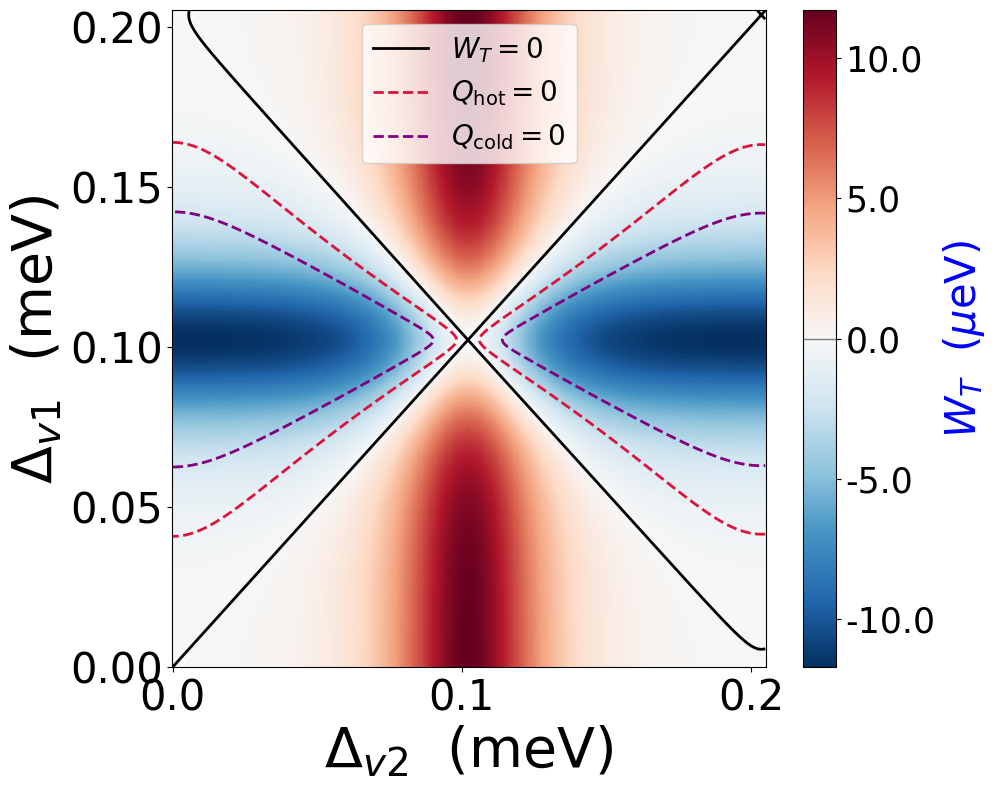

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import brentq
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker


# ── Stirling cycle ────────────────────────────────────────────

def stirling(Dv, energies, Dv1, Tc, Th):
    """
    For fixed Dv1, Tc, Th — sweep Dv2 over all Dv values
    and compute Qhot, Qcold, WT of the Stirling cycle.
    """
    def interp_F(dv_val, T):
        return np.interp(dv_val, Dv, free_energy(Dv, energies, T))

    def interp_S(dv_val, T):
        return np.interp(dv_val, Dv, entropy(Dv, energies, T))

    def interp_U(dv_val, T):
        return np.interp(dv_val, Dv, internal_energy(Dv, energies, T))

    # Fixed Dv1 quantities
    F1_Th = interp_F(Dv1, Th);  F1_Tc = interp_F(Dv1, Tc)
    S1_Th = interp_S(Dv1, Th);  S1_Tc = interp_S(Dv1, Tc)
    U1_Th = interp_U(Dv1, Th);  U1_Tc = interp_U(Dv1, Tc)

    Qhot_arr  = []
    Qcold_arr = []
    WT_arr    = []

    for dv2 in Dv:
        F2_Th = interp_F(dv2, Th);  F2_Tc = interp_F(dv2, Tc)
        S2_Th = interp_S(dv2, Th);  S2_Tc = interp_S(dv2, Tc)
        U2_Th = interp_U(dv2, Th);  U2_Tc = interp_U(dv2, Tc)

        W1  = -(F2_Th - F1_Th)
        Qh1 =  Th * (S2_Th - S1_Th)
        Qc2 =  U2_Tc - U2_Th
        W3  = -(F1_Tc - F2_Tc)
        Qc3 =  Tc * (S1_Tc - S2_Tc)
        Qh4 =  U1_Th - U1_Tc

        Qhot_arr.append(Qh1 + Qh4)
        Qcold_arr.append(Qc2 + Qc3)
        WT_arr.append(W1 + W3)

    Qhot_arr  = np.array(Qhot_arr)
    Qcold_arr = np.array(Qcold_arr)
    WT_arr    = np.array(WT_arr)

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
    axes[0].plot(Dv, Qhot_arr,  color='red',   lw=1.2)
    axes[0].set_ylabel(r'$Q_\mathrm{hot}$ (meV)')
    axes[0].set_title(rf'Stirling Cycle: $\Delta V_1={Dv1}$, $T_c={Tc}$ K, $T_h={Th}$ K')
    axes[0].axhline(0, color='gray', lw=0.5, ls='--')
    axes[1].plot(Dv, Qcold_arr, color='blue',  lw=1.2)
    axes[1].set_ylabel(r'$Q_\mathrm{cold}$ (meV)')
    axes[1].axhline(0, color='gray', lw=0.5, ls='--')
    axes[2].plot(Dv, WT_arr,    color='green', lw=1.2)
    axes[2].set_ylabel(r'$W_T$ (meV)')
    axes[2].set_xlabel(r'$\Delta V_2$ (meV·m)')
    axes[2].axhline(0, color='gray', lw=0.5, ls='--')
    plt.tight_layout()
    plt.show()

    return Qhot_arr, Qcold_arr, WT_arr

# ── Stirling heatmap ──────────────────────────────────────────
def stirling_heatmap(Dv, energies, Tc, Th, n=80, save=False):
    Dv_grid   = np.linspace(Dv[0], Dv[-1], n)
    WT_map    = np.full((n, n), np.nan)
    Qhot_map  = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)

    # Precompute once
    F_Th = free_energy(Dv, energies, Th);  F_Tc = free_energy(Dv, energies, Tc)
    S_Th = entropy(Dv, energies, Th);      S_Tc = entropy(Dv, energies, Tc)
    U_Th = internal_energy(Dv, energies, Th)
    U_Tc = internal_energy(Dv, energies, Tc)

    def get(arr, dv): return np.interp(dv, Dv, arr)

    for i, dv1 in enumerate(Dv_grid):
        F1_Th = get(F_Th, dv1);  F1_Tc = get(F_Tc, dv1)
        S1_Th = get(S_Th, dv1);  S1_Tc = get(S_Tc, dv1)
        U1_Th = get(U_Th, dv1);  U1_Tc = get(U_Tc, dv1)

        for j, dv2 in enumerate(Dv_grid):
            F2_Th = get(F_Th, dv2);  F2_Tc = get(F_Tc, dv2)
            S2_Th = get(S_Th, dv2);  S2_Tc = get(S_Tc, dv2)
            U2_Th = get(U_Th, dv2);  U2_Tc = get(U_Tc, dv2)

            W1  = -(F2_Th - F1_Th)
            Qh1 =  Th * (S2_Th - S1_Th)
            Qc2 =  U2_Tc - U2_Th
            W3  = -(F1_Tc - F2_Tc)
            Qc3 =  Tc * (S1_Tc - S2_Tc)
            Qh4 =  U1_Th - U1_Tc

            Qhot  = Qh1 + Qh4
            Qcold = Qc2 + Qc3
            WT    = W1  + W3

            Qhot_map[i, j]  = Qhot
            Qcold_map[i, j] = Qcold
            WT_map[i, j]    = WT*1000

            if   Qhot > 0 and Qcold < 0 and WT > 0: regime_map[i, j] = 1
            elif Qhot < 0 and Qcold > 0 and WT < 0: regime_map[i, j] = 2
            elif Qhot > 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 3
            elif Qhot < 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 4

    WT_masked = np.where(regime_map > 0, WT_map, np.nan)

    # Get min and max values for the colorbar (excluding NaN)
    vmin = np.nanmin(WT_masked)
    vmax = np.nanmax(WT_masked)

    # Use TwoSlopeNorm to put white at zero
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(Dv_grid, Dv_grid, WT_masked,
                       cmap='RdBu_r', norm=norm, shading='auto')

    # Add colorbar with appropriate ticks
    # For colorbar
    cbar = plt.colorbar(im, ax=ax, label=r'$W_T$  ($\mu$eV)')
    cbar.ax.set_ylabel(r'$W_T$  ($\mu$eV)', fontsize=30,color='blue')  # Increase label size
    cbar.ax.tick_params(labelsize=25)  # Increase tick label size
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    # For axis ticks
    ax.tick_params(axis='both', labelsize=30)  # Increase axis tick label size

    # Optional: Add a white line at zero to emphasize it
    cbar.ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)

    cs_kw = dict(linewidths=2)
    ax.contour(Dv_grid, Dv_grid, WT_map,    levels=[0], colors='black',   **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qhot_map,  levels=[0], colors='crimson',
               linestyles='--', **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qcold_map, levels=[0], colors='purple',
               linestyles='--',  **cs_kw)
    ax.legend(handles=[
        Line2D([0],[0], color='black',   lw=2, ls='-',  label=r'$W_T=0$'),
        Line2D([0],[0], color='crimson', lw=2, ls='--', label=r'$Q_\mathrm{hot}=0$'),
        Line2D([0],[0], color='purple',  lw=2, ls='--',  label=r'$Q_\mathrm{cold}=0$'),
    ], fontsize=20, loc='upper center')
    ax.set_xlabel(r'$\Delta_{v2}$  (meV)', fontsize=40)
    ax.set_ylabel(r'$\Delta_{v1}$  (meV)', fontsize=40)
    #ax.set_title(rf'$W_T(\Delta_{{v1}}, \Delta_{{v2}})$ — $T_c={Tc}$ K, $T_h={Th}$ K',
    #             fontsize=13)
    plt.tight_layout()
    plt.savefig('3Fig3a.png', dpi=150, bbox_inches='tight')
    plt.show()
    return Dv_grid, WT_masked, regime_map

data     = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)
Dv       = data[:, 0]
energies = data[:, 1:9]

Dv_grid, WT_masked, regime_map = stirling_heatmap(Dv, energies, Tc=0.05, Th=0.10, n=550)

Computing COP/eta heatmap for all regimes...
  row 0/1000
  row 10/1000
  row 20/1000
  row 30/1000
  row 40/1000
  row 50/1000
  row 60/1000
  row 70/1000
  row 80/1000
  row 90/1000
  row 100/1000
  row 110/1000
  row 120/1000
  row 130/1000
  row 140/1000
  row 150/1000
  row 160/1000
  row 170/1000
  row 180/1000
  row 190/1000
  row 200/1000
  row 210/1000
  row 220/1000
  row 230/1000
  row 240/1000
  row 250/1000
  row 260/1000
  row 270/1000
  row 280/1000
  row 290/1000
  row 300/1000
  row 310/1000
  row 320/1000
  row 330/1000
  row 340/1000
  row 350/1000
  row 360/1000
  row 370/1000
  row 380/1000
  row 390/1000
  row 400/1000
  row 410/1000
  row 420/1000
  row 430/1000
  row 440/1000
  row 450/1000
  row 460/1000
  row 470/1000
  row 480/1000
  row 490/1000
  row 500/1000
  row 510/1000
  row 520/1000
  row 530/1000
  row 540/1000
  row 550/1000
  row 560/1000
  row 570/1000
  row 580/1000
  row 590/1000
  row 600/1000
  row 610/1000
  row 620/1000
  row 630/1000
  row 

/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29404/555542398.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


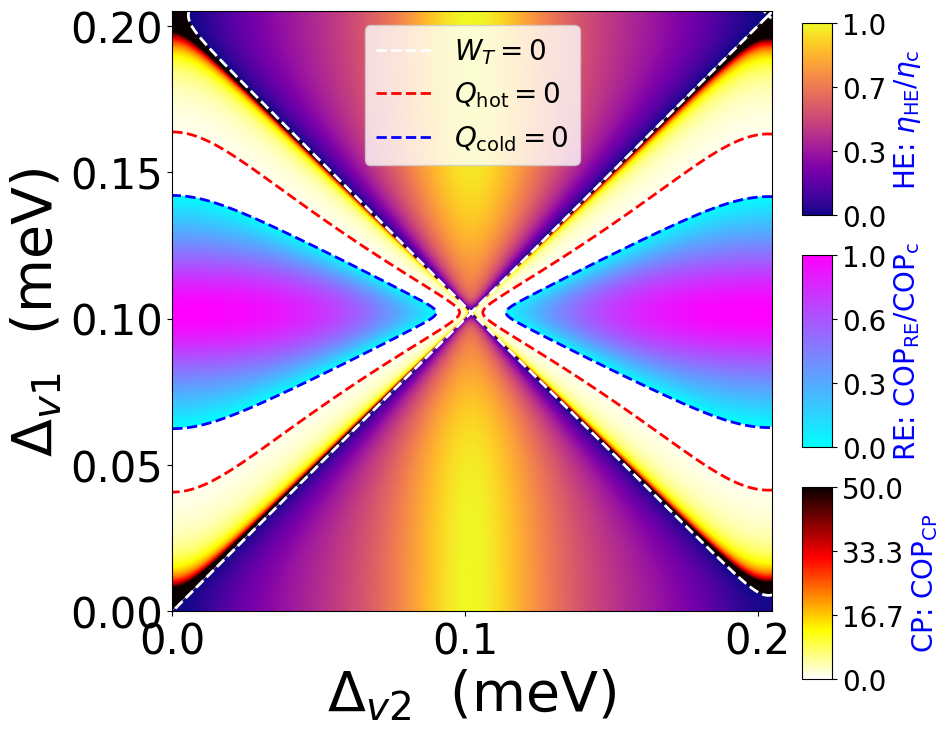

ValueError: too many values to unpack (expected 3)

In [3]:
def cop_heatmap(Dv, energies, Tc, Th, n=80, save=False):
    COP_c = Tc / (Th - Tc)
    eta_c = 1 - Tc/Th
    Dv_grid = np.linspace(Dv[0], Dv[-1], n)

    # Initialize maps for all regimes
    combined_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)
    Qcold_map = np.full((n, n), np.nan)
    Qhot_map = np.full((n, n), np.nan)
    WT_map = np.full((n, n), np.nan)

    # Store values for each regime separately
    engine_values = np.full((n, n), np.nan)
    refrigerator_values = np.full((n, n), np.nan)
    coldpump_values = np.full((n, n), np.nan)

    F_Th = free_energy(Dv, energies, Th);  F_Tc = free_energy(Dv, energies, Tc)
    S_Th = entropy(Dv, energies, Th);      S_Tc = entropy(Dv, energies, Tc)
    U_Th = internal_energy(Dv, energies, Th)
    U_Tc = internal_energy(Dv, energies, Tc)

    def get(arr, dv): return np.interp(dv, Dv, arr)

    print("Computing COP/eta heatmap for all regimes...")
    for i, dv1 in enumerate(Dv_grid):
        if i % 10 == 0:
            print(f"  row {i}/{n}")
        F1_Th = get(F_Th, dv1);  F1_Tc = get(F_Tc, dv1)
        S1_Th = get(S_Th, dv1);  S1_Tc = get(S_Tc, dv1)
        U1_Th = get(U_Th, dv1);  U1_Tc = get(U_Tc, dv1)

        for j, dv2 in enumerate(Dv_grid):
            F2_Th = get(F_Th, dv2);  F2_Tc = get(F_Tc, dv2)
            S2_Th = get(S_Th, dv2);  S2_Tc = get(S_Tc, dv2)
            U2_Th = get(U_Th, dv2);  U2_Tc = get(U_Tc, dv2)

            W1  = -(F2_Th - F1_Th)
            Qh1 =  Th * (S2_Th - S1_Th)
            Qc2 =  U2_Tc - U2_Th
            W3  = -(F1_Tc - F2_Tc)
            Qc3 =  Tc * (S1_Tc - S2_Tc)
            Qh4 =  U1_Th - U1_Tc

            Qhot  = Qh1 + Qh4
            Qcold = Qc2 + Qc3
            WT    = W1  + W3

            Qcold_map[i, j] = Qcold
            Qhot_map[i, j] = Qhot
            WT_map[i, j] = WT

            # Heat Engine regime: Qhot > 0, Qcold < 0, WT > 0
            if Qhot > 0 and Qcold < 0 and WT > 0:
                regime_map[i, j] = 1
                engine_values[i, j] = (WT / Qhot) / eta_c
                combined_map[i, j] = engine_values[i, j]

            # Refrigerator regime: Qhot < 0, Qcold > 0, WT < 0
            elif Qhot < 0 and Qcold > 0 and WT < 0:
                regime_map[i, j] = 2
                refrigerator_values[i, j] = (abs(Qcold) / abs(WT)) / COP_c
                combined_map[i, j] = refrigerator_values[i, j]

            # Cold Pump regime: Qhot > 0, Qcold < 0, WT < 0
            elif Qhot > 0 and Qcold < 0 and WT < 0:
                regime_map[i, j] = 3
                coldpump_values[i, j] = min(abs(Qcold) / abs(WT), 50)
                combined_map[i, j] = coldpump_values[i, j]

    # Create RGB image with white for invalid regions
    rgb_image = np.ones((n, n, 3))  # Start with white (1,1,1)

    # Get colormaps
    plasma_cmap = plt.cm.plasma
    cool_cmap = plt.cm.cool
    hot_cmap = plt.cm.hot_r

    engine_mask = (regime_map == 1)
    ref_mask = (regime_map == 2)
    pump_mask = (regime_map == 3)

    # Store colorbar info
    colorbar_info = {}

    if np.any(engine_mask):
        engine_vals = engine_values[engine_mask]
        vmin_engine = 0
        vmax_engine = np.nanmax(engine_vals)
        engine_norm = plt.Normalize(vmin=vmin_engine, vmax=vmax_engine)(engine_vals)
        engine_colors = plasma_cmap(engine_norm)
        rgb_image[engine_mask] = engine_colors[:, :3]
        colorbar_info['engine'] = {
            'vmin': vmin_engine,
            'vmax': vmax_engine,
            'cmap': plasma_cmap,
            'label': r"HE: $\eta_{\mathrm{HE}}/\eta_{\mathrm{c}}$"
        }
        print(f"HE range: {vmin_engine:.3f} to {vmax_engine:.3f}")

    if np.any(ref_mask):
        ref_vals = refrigerator_values[ref_mask]
        vmin_ref = 0
        vmax_ref = np.nanmax(ref_vals)
        ref_norm = plt.Normalize(vmin=vmin_ref, vmax=vmax_ref)(ref_vals)
        ref_colors = cool_cmap(ref_norm)
        rgb_image[ref_mask] = ref_colors[:, :3]
        colorbar_info['refrigerator'] = {
            'vmin': vmin_ref,
            'vmax': vmax_ref,
            'cmap': cool_cmap,
            'label': r"RE: $\mathrm{COP_{\mathrm{RE}}}/\mathrm{COP}_{\mathrm{c}}$"
        }
        print(f"Refrigerator range: {vmin_ref:.3f} to {vmax_ref:.3f}")

    if np.any(pump_mask):
        pump_vals = coldpump_values[pump_mask]
        vmin_pump = 0
        vmax_pump = 50  # Capped at 50
        pump_norm = plt.Normalize(vmin=vmin_pump, vmax=vmax_pump)(pump_vals)
        pump_colors = hot_cmap(pump_norm)
        rgb_image[pump_mask] = pump_colors[:, :3]
        colorbar_info['coldpump'] = {
            'vmin': vmin_pump,
            'vmax': vmax_pump,
            'cmap': hot_cmap,
            'label': r"CP: $\mathrm{COP_{\mathrm{CP}}} $"
        }
        print(f"Cold Pump range: {vmin_pump:.3f} to {vmax_pump:.3f}")

    # Create figure with specific size
    fig = plt.figure(figsize=(10, 8))

    # Create main plot axis (positioned on the left)
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])  # Main plot square-like

    # Create three separate axes for colorbars on the right
    cbar_width = 0.03
    cbar_spacing = 0.05
    cbar_start_x = 0.73

    # Calculate positions for three colorbars
    cbar_height = 0.24
    total_height = 3 * cbar_height + 2 * cbar_spacing
    start_y = (0.8 - total_height) / 2 + 0.05

    # Top colorbar (Heat Engine)
    cbar_ax1 = fig.add_axes([cbar_start_x, start_y + 2*(cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Middle colorbar (Refrigerator)
    cbar_ax2 = fig.add_axes([cbar_start_x, start_y + (cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Bottom colorbar (Cold Pump)
    cbar_ax3 = fig.add_axes([cbar_start_x, start_y,
                             cbar_width, cbar_height])

    # Display the RGB image in the main plot
    im = ax.imshow(rgb_image, extent=[Dv_grid[0], Dv_grid[-1], Dv_grid[0], Dv_grid[-1]],
                   origin='lower', aspect='equal')

    # Add contour lines
    cs_kw = dict(linewidths=2)
    ax.contour(Dv_grid, Dv_grid, WT_map, levels=[0],
               colors="white", linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qhot_map, levels=[0],
               colors="red", linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qcold_map, levels=[0],
               colors="blue", linestyles="--", **cs_kw)



    if 'engine' in colorbar_info:
        engine_norm = plt.Normalize(colorbar_info['engine']['vmin'],
                                    colorbar_info['engine']['vmax'])
        engine_sm = plt.cm.ScalarMappable(cmap=colorbar_info['engine']['cmap'],
                                          norm=engine_norm)
        engine_sm.set_array([])
        cbar1 = plt.colorbar(engine_sm, cax=cbar_ax1, orientation='vertical')
        cbar1.set_label(colorbar_info['engine']['label'], fontsize=20, color="blue")
        cbar1.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['engine']['vmin']
        vmax = colorbar_info['engine']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar1.set_ticks(ticks)
        # Optional: format ticks to show 1 decimal place
        cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'refrigerator' in colorbar_info:
        ref_norm = plt.Normalize(colorbar_info['refrigerator']['vmin'],
                                 colorbar_info['refrigerator']['vmax'])
        ref_sm = plt.cm.ScalarMappable(cmap=colorbar_info['refrigerator']['cmap'],
                                       norm=ref_norm)
        ref_sm.set_array([])
        cbar2 = plt.colorbar(ref_sm, cax=cbar_ax2, orientation='vertical')
        cbar2.set_label(colorbar_info['refrigerator']['label'], fontsize=20, color="blue")
        cbar2.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['refrigerator']['vmin']
        vmax = colorbar_info['refrigerator']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar2.set_ticks(ticks)
        cbar2.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'coldpump' in colorbar_info:
        pump_norm = plt.Normalize(colorbar_info['coldpump']['vmin'],
                                  colorbar_info['coldpump']['vmax'])
        pump_sm = plt.cm.ScalarMappable(cmap=colorbar_info['coldpump']['cmap'],
                                        norm=pump_norm)
        pump_sm.set_array([])
        cbar3 = plt.colorbar(pump_sm, cax=cbar_ax3, orientation='vertical')
        cbar3.set_label(colorbar_info['coldpump']['label'], fontsize=20, color="blue")
        cbar3.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['coldpump']['vmin']
        vmax = colorbar_info['coldpump']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar3.set_ticks(ticks)
        cbar3.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # Legend (placed inside the main plot)
    legend_elements = [
        Line2D([0], [0], color="white", lw=2, ls="--", label=r"$W_T = 0$"),
        Line2D([0], [0], color="red", lw=2, ls="--", label=r"$Q_{\mathrm{hot}} = 0$"),
        Line2D([0], [0], color="blue", lw=2, ls="--", label=r"$Q_{\mathrm{cold}} = 0$")
    ]

    ax.legend(handles=legend_elements, fontsize=20, loc="upper center")

    # Set ticks and labels
    ax.set_xlabel(r'$\Delta_{v2}$  (meV)', fontsize=40)
    ax.set_ylabel(r'$\Delta_{v1}$  (meV)', fontsize=40)
    ax.tick_params(axis='both', labelsize=30)

    # Add title
    #ax.set_title(rf"Performance Maps — $T_c={Tc}$ K, $T_h={Th}$ K, "
    #             rf"$\eta_c={eta_c:.3f}$, $\mathrm{{COP}}_c={COP_c:.3f}$",
    #             fontsize=14, pad=20)

    # Add statistics text box (optional)
    n_engine = np.sum(regime_map == 1)
    n_ref = np.sum(regime_map == 2)
    n_pump = np.sum(regime_map == 3)
    n_invalid = n*n - n_engine - n_ref - n_pump

    #stats_text = f"Points: Engine={n_engine}, Ref={n_ref}, Pump={n_pump}, Invalid={n_invalid}"
    #ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
    #        fontsize=10, verticalalignment='bottom',
    #        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()

    plt.savefig('3Fig3b.png', dpi=150, bbox_inches='tight')

    plt.show()

    return (Dv_grid, combined_map, regime_map, WT_map, Qhot_map, Qcold_map,
            engine_values, refrigerator_values, coldpump_values)

Dv_grid, cop_map, Qcold_map = cop_heatmap(Dv, energies, Tc=0.05, Th=0.10, n=1000)